# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/betmutema/ml-engineering-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [1]:
import os, getpass, duckdb, pandas as pd, numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('HF token: ')
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
fact = f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"
dim_content = f"read_parquet('{REL}/dim_content.parquet')"
ANCHOR = "DATE '2026-03-31'"

span = con.sql(f"""
    SELECT COUNT(*) n_rows, MIN(report_date) d_min, MAX(report_date) d_max,
           COUNT(DISTINCT content_hash_id) n_content, COUNT(DISTINCT client_hash_id) n_clients
    FROM {fact}
    WHERE report_date BETWEEN {ANCHOR} - INTERVAL 60 DAY AND {ANCHOR}
""").df()
print(span)

HF token: ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

     n_rows      d_min      d_max  n_content  n_clients
0  17717009 2026-01-30 2026-03-31     349411         59


Data source is the FlyRank ML Engineering Internship warehouse release (**fact_content_daily_performance**, ~79M rows total; dim_content), a 60-day window ending 2026-03-31 (a mid-panel month, the sealed final month is deliberately excluded from all development per the dataset's own documentation). **fact_content_query_90d** was excluded, its fixed 90-day window overlaps the 30-day label window with no way to split it safely. Raw GA4 columns were excluded, only 3.2% of rows have GA4 data available. All identifiers are client/content hashes; no client names, URLs, or raw queries appear anywhere.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [2]:
features = con.sql(f"""
    SELECT f.client_hash_id, f.content_hash_id,
        SUM(CASE WHEN f.report_date >  {ANCHOR} - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
        SUM(CASE WHEN f.report_date <= {ANCHOR} - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
        SUM(CASE WHEN f.report_date <= {ANCHOR} - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_prev30,
        AVG(CASE WHEN f.report_date <= {ANCHOR} - INTERVAL 30 DAY THEN f.gsc_avg_position END)        AS pos_prev30
    FROM {fact} f
    WHERE f.report_date BETWEEN {ANCHOR} - INTERVAL 60 DAY AND {ANCHOR}
    GROUP BY 1,2 HAVING imp_prev30 >= 100
""").df()
features['ctr_prev30'] = features['clk_prev30'] / features['imp_prev30']
features = features.merge(
    con.sql(f"""SELECT content_hash_id, DATE_DIFF('day', content_created_date, {ANCHOR}) AS content_age_days
                FROM {dim_content}""").df(),
    on='content_hash_id', how='left'
)
features['is_declining'] = (features['imp_last30'] < 0.8 * features['imp_prev30']).astype(int)
features = features.dropna(subset=['pos_prev30', 'content_age_days']).reset_index(drop=True)

FEATURE_COLS = ['imp_prev30', 'clk_prev30', 'pos_prev30', 'ctr_prev30', 'content_age_days']

# Leakage check
print("Single-feature AUC check (smell test for leakage):")
for col in FEATURE_COLS:
    print(f"  {col}: {roc_auc_score(features['is_declining'], features[col]):.3f}")

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(features, groups=features['client_hash_id']))
train, test = features.iloc[train_idx].copy(), features.iloc[test_idx].copy()
print(f"\nTrain/test client overlap: {len(set(train.client_hash_id) & set(test.client_hash_id))} (should be 0)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Single-feature AUC check (smell test for leakage):
  imp_prev30: 0.450
  clk_prev30: 0.421
  pos_prev30: 0.500
  ctr_prev30: 0.422
  content_age_days: 0.550

Train/test client overlap: 0 (should be 0)


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [3]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

# Baseline rule (ML-07)
stale = (test['content_age_days'] >= 365).astype(int)
visible = (test['imp_prev30'] >= 250).astype(int)
baseline_scores = stale * visible * test['imp_prev30']

# Naive (ungrouped) split for comparison — shows why the honest split matters
X, y, groups = features[FEATURE_COLS], features['is_declining'], features['client_hash_id']
from sklearn.model_selection import train_test_split
X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
rf_naive = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf_naive.fit(X_tr_n, y_tr_n)
naive_precision = precision_at_k(rf_naive.predict_proba(X_te_n)[:, 1], y_te_n, 50)

# Honest grouped split
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(train[FEATURE_COLS], train['is_declining'])
test['model_score'] = rf.predict_proba(test[FEATURE_COLS])[:, 1]

results = pd.DataFrame({
    'method': ['Base rate', 'Baseline rule (ML-07)', 'Random Forest — naive split', 'Random Forest — grouped/honest split'],
    'precision_at_50': [
        test['is_declining'].mean(),
        precision_at_k(baseline_scores, test['is_declining'], 50),
        naive_precision,
        precision_at_k(test['model_score'], test['is_declining'], 50),
    ]
}).round(3)
print(results)

perm = permutation_importance(rf, test[FEATURE_COLS], test['is_declining'], n_repeats=10, random_state=42, n_jobs=-1)
importance = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)
print("\nPermutation importance (grouped model):")
print(importance.round(4))

                                 method  precision_at_50
0                             Base rate            0.279
1                 Baseline rule (ML-07)            0.100
2           Random Forest — naive split            0.880
3  Random Forest — grouped/honest split            0.200

Permutation importance (grouped model):
ctr_prev30          0.0010
content_age_days   -0.0029
pos_prev30         -0.0032
imp_prev30         -0.0058
clk_prev30         -0.0065
dtype: float64


## 5. Limitations

*What this work cannot claim.*

In [4]:
print("Key limitation, stated with numbers:")
print(f"Naive split precision@50: {naive_precision:.3f} (looked strong)")
print(f"Honest grouped-split precision@50: {precision_at_k(test['model_score'], test['is_declining'], 50):.3f} (did not beat base rate)")
print(f"Base rate: {test['is_declining'].mean():.3f}")
top10 = test.sort_values('model_score', ascending=False).head(10)
print(f"\nTop-10 client concentration: {top10['client_hash_id'].value_counts(normalize=True).iloc[0]:.1%}")

Key limitation, stated with numbers:
Naive split precision@50: 0.880 (looked strong)
Honest grouped-split precision@50: 0.200 (did not beat base rate)
Base rate: 0.279

Top-10 client concentration: 100.0%


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [5]:
test['reason_code'] = np.where((stale.values & visible.values) == 1, 'stale_but_visible', 'model_flagged_only')
queue = test.sort_values('model_score', ascending=False).reset_index(drop=True)
queue['rank'] = queue.index + 1
queue['archetype'] = np.where(queue['reason_code'] == 'stale_but_visible', 'refresh_candidate', 'investigate_decline')
queue['recommended_action'] = np.where(queue['archetype'] == 'refresh_candidate',
                                         'Content refresh review', 'Manual investigation before any action')
print(queue[['rank','client_hash_id','model_score','archetype','recommended_action']].head(10))

   rank           client_hash_id  model_score            archetype  \
0     1  client_62f4a7e64f5e0096     0.662647  investigate_decline   
1     2  client_62f4a7e64f5e0096     0.662647  investigate_decline   
2     3  client_62f4a7e64f5e0096     0.662647  investigate_decline   
3     4  client_62f4a7e64f5e0096     0.662324  investigate_decline   
4     5  client_62f4a7e64f5e0096     0.661931  investigate_decline   
5     6  client_62f4a7e64f5e0096     0.660949  investigate_decline   
6     7  client_62f4a7e64f5e0096     0.660469  investigate_decline   
7     8  client_62f4a7e64f5e0096     0.658917  investigate_decline   
8     9  client_62f4a7e64f5e0096     0.657647  investigate_decline   
9    10  client_62f4a7e64f5e0096     0.657210  investigate_decline   

                       recommended_action  
0  Manual investigation before any action  
1  Manual investigation before any action  
2  Manual investigation before any action  
3  Manual investigation before any action  
4  Manual

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Artifacts saved to work/figures/ and work/outputs/


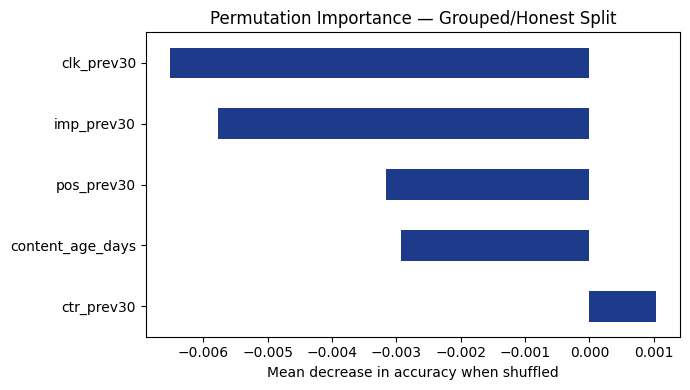

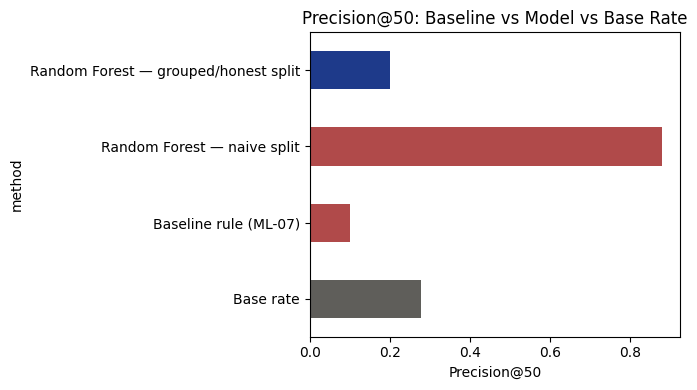

In [8]:
import matplotlib.pyplot as plt
os.makedirs('work/figures', exist_ok=True)
os.makedirs('work/outputs', exist_ok=True)

fig, ax = plt.subplots(figsize=(7,4))
importance.plot(kind='barh', ax=ax, color='#1E3A8A')
ax.set_title("Permutation Importance — Grouped/Honest Split")
ax.set_xlabel("Mean decrease in accuracy when shuffled")
plt.tight_layout()
plt.savefig('work/figures/permutation_importance.png', dpi=150)

fig2, ax2 = plt.subplots(figsize=(7,4))
results.set_index('method')['precision_at_50'].plot(kind='barh', ax=ax2, color=['#5F5E5A','#B04A4A','#B04A4A','#1E3A8A'])
ax2.set_title("Precision@50: Baseline vs Model vs Base Rate")
ax2.set_xlabel("Precision@50")
plt.tight_layout()
plt.savefig('work/figures/precision_comparison.png', dpi=150)

results.to_json('work/outputs/results_metrics.json', orient='records', indent=2)
queue.head(50).to_csv('work/outputs/ranked_queue_top50.csv', index=False)
print("Artifacts saved to work/figures/ and work/outputs/")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.